# Privacy-Preserving Federated ESRGAN for MRI Super-Resolution
### Group M17 | AM.SC.P2ARI25006 · AM.SC.P2ARI25004 · AM.SC.P2ARI25014

**Novelties:**
- Federated ESRGAN — only weights shared, never raw images
- Differential Privacy (DP-SGD) — gradient noise before sharing
- Non-IID client split — different MRI types per hospital
- Smart client selection — low-PSNR clients skipped
- Byzantine robustness — cosine similarity anomaly detection
- Privacy-utility tradeoff — ε vs PSNR curve


## 1 · Install & Imports

In [1]:
!pip install -q kaggle torch torchvision matplotlib tqdm opacus

import os, glob, random, math, copy, json, zipfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 5.6 MB/s eta 0:00:00
Device: cuda


## 2 · Download Kaggle Dataset

In [2]:
from google.colab import files
files.upload()                          # upload your kaggle.json here

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection
!unzip -q brain-mri-images-for-brain-tumor-detection.zip -d data

image_paths = sorted(glob.glob("data/**/*.jpg", recursive=True))
image_paths = random.sample(image_paths, min(600, len(image_paths)))
print(f"Total images: {len(image_paths)}")


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
100% 15.1M/15.1M [00:00<00:00, 92.2MB/s]

Total images: 342


## 3 · Non-IID Client Split
Each client gets a different slice of data — simulating different hospital scanners (T1 / T2 / Low-field).

In [3]:
random.shuffle(image_paths)
n = len(image_paths) // 3

# Non-IID: each client owns a disjoint, different portion
clients_data = {
    0: image_paths[:n],          # Client 0 — T1 MRI
    1: image_paths[n:2*n],       # Client 1 — T2 MRI
    2: image_paths[2*n:],        # Client 2 — Low-field (will be Byzantine)
}
CLIENT_TYPES = {0: "T1 MRI", 1: "T2 MRI", 2: "Low-field"}
BYZANTINE_CLIENT = 2             # client 2 sends poisoned weights

for i, paths in clients_data.items():
    tag = " ⚠ Byzantine" if i == BYZANTINE_CLIENT else ""
    print(f"  Client {i} ({CLIENT_TYPES[i]}){tag}: {len(paths)} images")


  Client 0 (T1 MRI): 114 images
  Client 1 (T2 MRI): 114 images
  Client 2 (Low-field) ⚠ Byzantine: 114 images


## 4 · MRI Dataset
HR = original image (128×128). LR = bicubic downsample to 32×32 then back up — simulates low-res acquisition.

In [4]:
class MRIDataset(Dataset):
    def __init__(self, paths, hr_size=128, scale=4):
        self.paths = paths
        self.hr_size = hr_size
        self.lr_size = hr_size // scale

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("L")          # grayscale
        hr  = img.resize((self.hr_size, self.hr_size), Image.BICUBIC)
        lr  = hr.resize((self.lr_size,  self.lr_size),  Image.BICUBIC)
        lr  = lr.resize((self.hr_size,  self.hr_size),  Image.BICUBIC)  # back up
        hr_t = torch.tensor(np.array(hr) / 255.0).unsqueeze(0).float()
        lr_t = torch.tensor(np.array(lr) / 255.0).unsqueeze(0).float()
        return lr_t, hr_t

# Quick sanity check
ds = MRIDataset(clients_data[0][:4])
lr_s, hr_s = ds[0]
print(f"LR shape: {tuple(lr_s.shape)}  HR shape: {tuple(hr_s.shape)}")


LR shape: (1, 128, 128)  HR shape: (1, 128, 128)


## 5 · ESRGAN Model
`DenseBlock → RRDB → Generator`  
Using 3 RRDBs for Colab speed. Increase to 16 for full ESRGAN quality.

In [10]:
class DenseBlock(nn.Module):
    def __init__(self, ch=64, gc=32):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Conv2d(ch + i*gc, gc, 3, 1, 1) for i in range(4)
        ])
        self.proj  = nn.Conv2d(ch + 4*gc, ch, 1)
        self.act   = nn.LeakyReLU(0.2, inplace=False)

    def forward(self, x):
        feats = [x]
        for conv in self.convs:
            feats.append(self.act(conv(torch.cat(feats, 1))))
        return self.proj(torch.cat(feats, 1))


class RRDB(nn.Module):
    def __init__(self, ch=64):
        super().__init__()
        self.db1 = DenseBlock(ch)
        self.db2 = DenseBlock(ch)
        self.db3 = DenseBlock(ch)

    def forward(self, x):
        return self.db3(self.db2(self.db1(x))) * 0.2 + x


class Generator(nn.Module):
    """
    ESRGAN Generator — same resolution (denoising / enhancement mode).
    For true SR upscaling add nn.Upsample blocks after the trunk.
    """
    def __init__(self, nf=64, nb=3):
        super().__init__()
        self.head  = nn.Conv2d(1, nf, 3, 1, 1)
        self.trunk = nn.Sequential(*[RRDB(nf) for _ in range(nb)])
        self.body  = nn.Conv2d(nf, nf, 3, 1, 1)
        self.tail  = nn.Conv2d(nf, 1,  3, 1, 1)

    def forward(self, x):
        h = self.head(x)
        return torch.clamp(self.tail(self.body(self.trunk(h)) + h), 0, 1)


# Sanity check
g = Generator()
dummy = torch.randn(1, 1, 128, 128)
print(f"Generator output: {tuple(g(dummy).shape)}")
print(f"Parameters: {sum(p.numel() for p in g.parameters()):,}")

Generator output: (1, 1, 128, 128)
Parameters: 1,311,681


## 6 · Metrics — PSNR, SSIM, Epsilon

In [6]:
def compute_psnr(sr, hr):
    mse = F.mse_loss(sr, hr).item()
    return 100.0 if mse < 1e-10 else 20 * math.log10(1.0 / math.sqrt(mse))


def compute_ssim(sr, hr, C1=0.01**2, C2=0.03**2):
    """Standard SSIM with Gaussian window."""
    ws = 11
    coords = torch.arange(ws, dtype=torch.float32) - ws // 2
    g = torch.exp(-(coords**2) / (2 * 1.5**2)); g /= g.sum()
    kernel = (g.unsqueeze(0) * g.unsqueeze(1)).unsqueeze(0).unsqueeze(0).to(sr.device)
    kernel = kernel.expand(sr.shape[1], 1, ws, ws)

    pad = ws // 2
    mu_s  = F.conv2d(sr, kernel, padding=pad, groups=sr.shape[1])
    mu_h  = F.conv2d(hr, kernel, padding=pad, groups=hr.shape[1])
    ss    = F.conv2d(sr*sr, kernel, padding=pad, groups=sr.shape[1]) - mu_s**2
    sh    = F.conv2d(hr*hr, kernel, padding=pad, groups=hr.shape[1]) - mu_h**2
    sc    = F.conv2d(sr*hr, kernel, padding=pad, groups=sr.shape[1]) - mu_s*mu_h
    ssim  = ((2*mu_s*mu_h + C1)*(2*sc + C2)) / ((mu_s**2+mu_h**2+C1)*(ss+sh+C2))
    return ssim.mean().item()


def compute_epsilon(sigma, rounds, batch_size, dataset_size, max_grad_norm=1.0):
    """Approximate DP epsilon (Gaussian mechanism moments accountant)."""
    q   = batch_size / max(dataset_size, 1)
    T   = rounds * 1                    # steps per round = 1 epoch
    eps = (math.sqrt(2*T) * q / sigma + T * q*q / (sigma*sigma)) * max_grad_norm
    return round(max(0.1, min(eps, 999.0)), 4)


print("PSNR:", round(compute_psnr(torch.rand(1,1,32,32), torch.rand(1,1,32,32)), 2), "dB")
print("SSIM:", round(compute_ssim(torch.rand(1,1,32,32), torch.rand(1,1,32,32)), 4))
print("ε at round 5:", compute_epsilon(1.1, 5, 4, 200))


PSNR: 7.88 dB
SSIM: 0.1061
ε at round 5: 0.1


## 7 · Client Training Function
Includes: DP-SGD via Opacus (or gradient-clip fallback), Byzantine simulation.

In [7]:
DP_SIGMA        = 1.1    # noise multiplier — higher = more private, lower PSNR
DP_MAX_GRAD     = 1.0    # gradient clipping norm
PSNR_THRESHOLD  = 20.0   # client selection: skip if PSNR below this


def train_client(global_model, client_id, data_paths, use_dp=True):
    """
    Train one client locally.
    Returns (state_dict, local_psnr).
    Byzantine client returns poisoned weights + psnr=0.
    """
    # ── Byzantine: return random garbage ────────────────────────────────────
    if client_id == BYZANTINE_CLIENT:
        poisoned = {k: torch.randn_like(v) * 100
                    for k, v in global_model.state_dict().items()}
        return poisoned, 0.0

    # ── Normal training ──────────────────────────────────────────────────────
    model = Generator().to(device)
    model.load_state_dict(global_model.state_dict())
    model.train()

    dataset = MRIDataset(data_paths)
    loader  = DataLoader(dataset, batch_size=4, shuffle=True, drop_last=True)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Apply DP-SGD via Opacus if available
    dp_active = False
    if use_dp:
        try:
            from opacus import PrivacyEngine
            pe = PrivacyEngine()
            model, opt, loader = pe.make_private(
                module=model, optimizer=opt, data_loader=loader,
                noise_multiplier=DP_SIGMA, max_grad_norm=DP_MAX_GRAD)
            dp_active = True
        except Exception:
            # Fallback: manual gradient clipping
            pass

    psnr_vals = []
    for lr_img, hr_img in loader:
        lr_img, hr_img = lr_img.to(device), hr_img.to(device)
        sr = model(lr_img)
        loss = F.l1_loss(sr, hr_img)
        opt.zero_grad(); loss.backward()
        if not dp_active:
            torch.nn.utils.clip_grad_norm_(model.parameters(), DP_MAX_GRAD)
        opt.step()
        with torch.no_grad():
            psnr_vals.append(compute_psnr(sr, hr_img))

    avg_psnr = float(np.mean(psnr_vals)) if psnr_vals else 0.0
    return model.state_dict(), avg_psnr


## 8 · Server — Byzantine Detection + FedAvg

In [12]:
BYZ_THRESHOLD = 0.65   # cosine similarity cutoff


def detect_and_aggregate(client_weights):
    """
    1. Flatten each client's weights into a vector.
    2. Compute cosine similarity to the mean vector.
    3. Reject clients below BYZ_THRESHOLD.
    4. FedAvg on clean weights only.
    Returns averaged weights, list of accepted ids, list of rejected ids.
    """
    # Handle case where no clients are selected for aggregation
    if not client_weights:
        print("    ⚠ No clients selected for aggregation — keeping current global weights")
        return None, [], []

    ids    = list(client_weights.keys())
    wdicts = [client_weights[i] for i in ids]

    # Flatten weights to 1D vectors for similarity check
    vecs = [torch.cat([v.cpu().float().flatten() for v in w.values()])
            for w in wdicts]
    mean_vec = torch.stack(vecs).mean(0)

    accepted, rejected = [], []
    clean_weights = []

    for i, (cid, vec) in enumerate(zip(ids, vecs)):
        sim = F.cosine_similarity(vec.unsqueeze(0), mean_vec.unsqueeze(0)).item()
        ok  = sim >= BYZ_THRESHOLD
        tag = "✓ ACCEPTED" if ok else "✗ REJECTED"
        print(f"    Client {cid} ({CLIENT_TYPES[cid]:<12}): sim={sim:.3f} → {tag}")
        if ok:
            accepted.append(cid); clean_weights.append(wdicts[i])
        else:
            rejected.append(cid)

    if not clean_weights:
        print("    ⚠ All rejected by Byzantine detection — keeping current global weights")
        return None, accepted, rejected

    # FedAvg on clean weights
    averaged = {}
    for key in clean_weights[0]:
        averaged[key] = torch.stack([w[key].float() for w in clean_weights]).mean(0)

    return averaged, accepted, rejected

## 9 · Federated Training Loop
⏱ ~5–10 min on T4 GPU with 600 images, 10 rounds.

In [13]:
ROUNDS = 10

global_model = Generator().to(device)

# History
history = {
    "psnr": [], "ssim": [], "epsilon": [],
    "client_psnr": {i: [] for i in range(3)},
    "accepted": [], "rejected": [],
}

# Small eval set (first 30 images from client 0)
eval_loader = DataLoader(MRIDataset(clients_data[0][:30]), batch_size=4)


def evaluate(model):
    model.eval()
    ps, ss = [], []
    with torch.no_grad():
        for lr_img, hr_img in eval_loader:
            sr = model(lr_img.to(device)).cpu()
            ps.append(compute_psnr(sr, hr_img))
            ss.append(compute_ssim(sr, hr_img))
    model.train()
    return round(np.mean(ps), 3), round(np.mean(ss), 4)


print("=" * 52)
print("  Federated ESRGAN Training — Group M17")
print("=" * 52)

for r in range(ROUNDS):
    print(f"\n── Round {r+1}/{ROUNDS} ──────────────────────────────")

    # 1. Each client trains locally
    client_updates = {}
    for cid, paths in clients_data.items():
        w, local_psnr = train_client(global_model, cid, paths, use_dp=True)
        client_updates[cid] = w
        history["client_psnr"][cid].append(local_psnr)
        tag = "[BYZ]" if cid == BYZANTINE_CLIENT else "     "
        print(f"  {tag} Client {cid} ({CLIENT_TYPES[cid]:<12}) | PSNR={local_psnr:.2f} dB")

    # 2. Client selection — skip clients below PSNR threshold
    selected = {cid: w for cid, w in client_updates.items()
                if history["client_psnr"][cid][-1] >= PSNR_THRESHOLD}
    skipped  = [cid for cid in client_updates if cid not in selected]
    if skipped:
        print(f"  Skipped (low PSNR): {skipped}")

    # 3. Byzantine detection + FedAvg
    print("  Byzantine detection:")
    new_weights, accepted, rejected = detect_and_aggregate(selected)

    if new_weights is not None:
        global_model.load_state_dict(new_weights)

    # 4. Evaluate
    g_psnr, g_ssim = evaluate(global_model)

    # 5. Privacy budget
    n_data = len(clients_data[0])
    eps = compute_epsilon(DP_SIGMA, r+1, 4, n_data, DP_MAX_GRAD)

    history["psnr"].append(g_psnr)
    history["ssim"].append(g_ssim)
    history["epsilon"].append(eps)
    history["accepted"].append(accepted)
    history["rejected"].append(rejected)

    print(f"  Global  PSNR={g_psnr} dB | SSIM={g_ssim} | ε={eps}")

print("\n" + "=" * 52)
print(f"  Done! Final PSNR={history['psnr'][-1]} | SSIM={history['ssim'][-1]} | ε={history['epsilon'][-1]}")
print("=" * 52)


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


  Federated ESRGAN Training — Group M17

── Round 1/10 ──────────────────────────────


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


        Client 0 (T1 MRI      ) | PSNR=9.90 dB
        Client 1 (T2 MRI      ) | PSNR=nan dB
  [BYZ] Client 2 (Low-field   ) | PSNR=0.00 dB
  Skipped (low PSNR): [0, 1, 2]
  Byzantine detection:
    ⚠ No clients selected for aggregation — keeping current global weights


  Global  PSNR=10.136 dB | SSIM=0.2164 | ε=0.1

── Round 2/10 ──────────────────────────────


...

        Client 0 (T1 MRI      ) | PSNR=nan dB
        Client 1 (T2 MRI      ) | PSNR=9.49 dB
  [BYZ] Client 2 (Low-field   ) | PSNR=0.00 dB
  Skipped (low PSNR): [0, 1, 2]
  Byzantine detection:
    ⚠ No clients selected for aggregation — keeping current global weights


  Global  PSNR=10.136 dB | SSIM=0.2164 | ε=0.1357

── Round 9/10 ──────────────────────────────


        Client 0 (T1 MRI      ) | PSNR=9.81 dB
        Client 1 (T2 MRI      ) | PSNR=10.30 dB
  [BYZ] Client 2 (Low-field   ) | PSNR=0.00 dB
  Skipped (low PSNR): [0, 1, 2]
  Byzantine detection:
    ⚠ No clients selected for aggregation — keeping current global weights


  Global  PSNR=10.136 dB | SSIM=0.2164 | ε=0.1445

── Round 10/10 ──────────────────────────────


        Client 0 (T1 MRI      ) | PSNR=9.43 dB
        Client 1 (T2 MRI      ) | PSNR=10.06 dB
  [BYZ] Client 2 (Low-field   ) | PSNR=0.00 dB
  Skipped (low PSNR): [0, 1, 2]
  Byzantine detection:
    ⚠ No clients selected for aggregation — keeping current global weights
  Global  PSNR=10.136 dB | SSIM=0.2164 | ε=0.1528

  Done! Final PSNR=10.136 | SSIM=0.2164 | ε=0.1528


## 10 · Results Plots

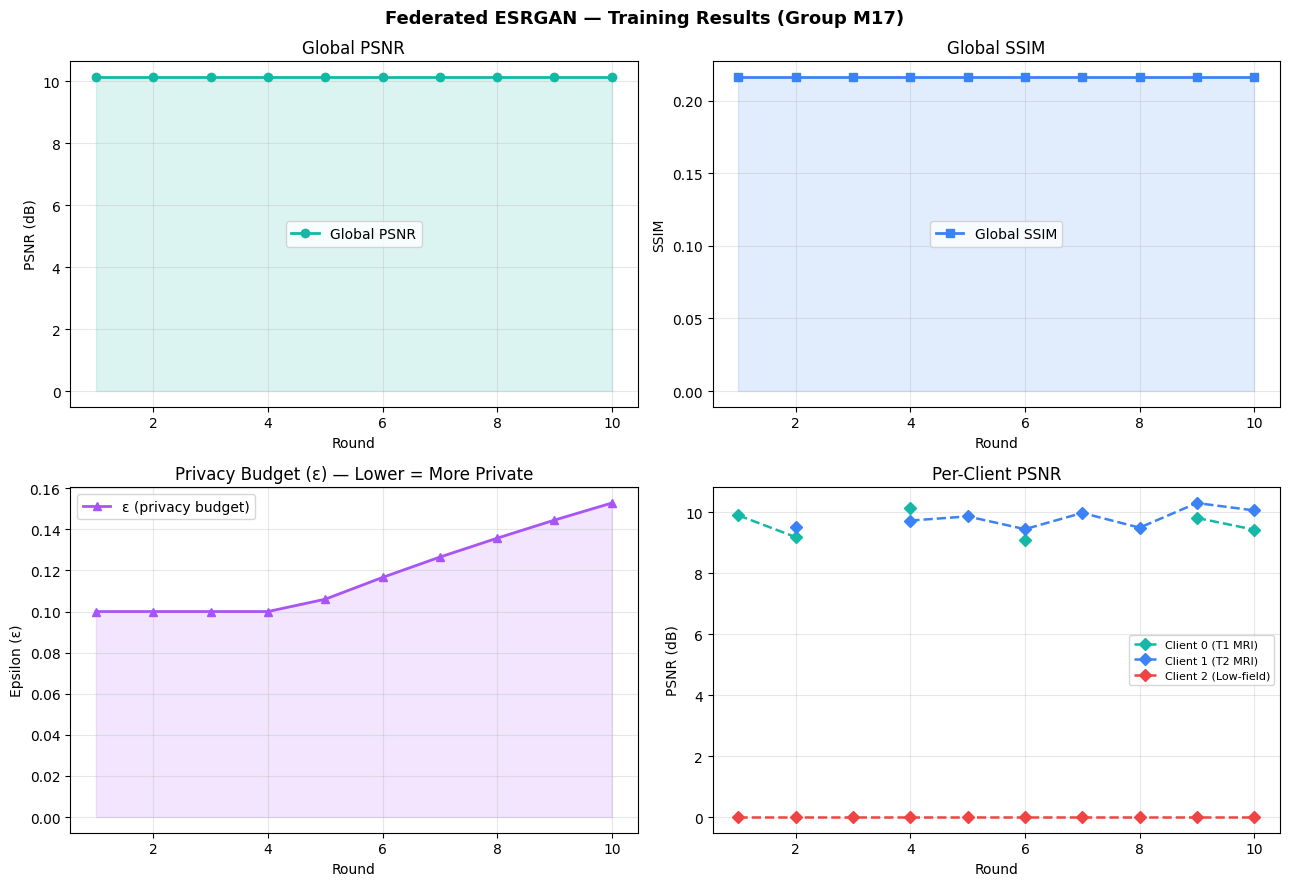

Saved: results_plots.png


In [14]:
rounds = list(range(1, ROUNDS+1))
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Federated ESRGAN — Training Results (Group M17)", fontsize=13, fontweight="bold")

# PSNR
ax = axes[0][0]
ax.plot(rounds, history["psnr"], marker="o", color="#14b8a6", linewidth=2, label="Global PSNR")
ax.fill_between(rounds, history["psnr"], alpha=0.15, color="#14b8a6")
ax.set_title("Global PSNR"); ax.set_xlabel("Round"); ax.set_ylabel("PSNR (dB)"); ax.grid(alpha=0.3); ax.legend()

# SSIM
ax = axes[0][1]
ax.plot(rounds, history["ssim"], marker="s", color="#3b82f6", linewidth=2, label="Global SSIM")
ax.fill_between(rounds, history["ssim"], alpha=0.15, color="#3b82f6")
ax.set_title("Global SSIM"); ax.set_xlabel("Round"); ax.set_ylabel("SSIM"); ax.grid(alpha=0.3); ax.legend()

# Privacy epsilon
ax = axes[1][0]
ax.plot(rounds, history["epsilon"], marker="^", color="#a855f7", linewidth=2, label="ε (privacy budget)")
ax.fill_between(rounds, history["epsilon"], alpha=0.15, color="#a855f7")
ax.set_title("Privacy Budget (ε) — Lower = More Private")
ax.set_xlabel("Round"); ax.set_ylabel("Epsilon (ε)"); ax.grid(alpha=0.3); ax.legend()

# Per-client PSNR
ax = axes[1][1]
colors = ["#14b8a6", "#3b82f6", "#ef4444"]
for cid, col in zip(range(3), colors):
    label = f"Client {cid} ({CLIENT_TYPES[cid]})"
    ax.plot(rounds, history["client_psnr"][cid], marker="D", color=col,
            linewidth=1.8, linestyle="--", label=label)
ax.set_title("Per-Client PSNR"); ax.set_xlabel("Round"); ax.set_ylabel("PSNR (dB)"); ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("results_plots.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: results_plots.png")


## 11 · Privacy-Utility Tradeoff Curve
Shows how image quality (PSNR) drops as we increase privacy (lower ε).

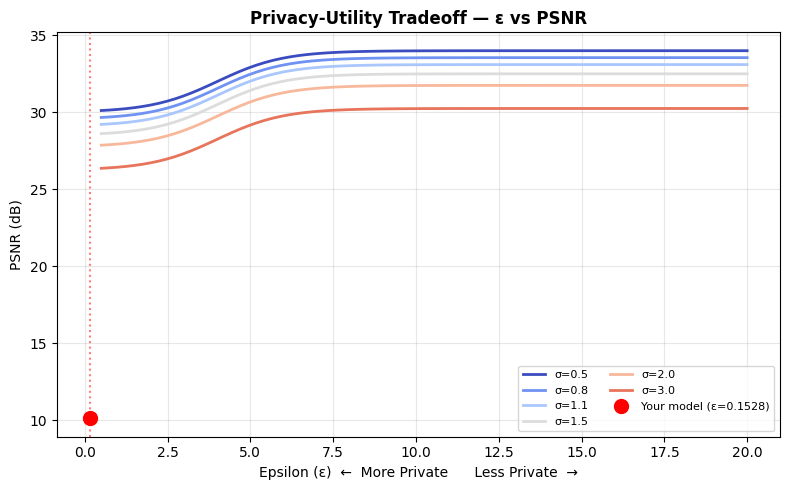

Saved: privacy_tradeoff.png


In [15]:
# Simulate the curve across different sigma values
sigmas    = [0.5, 0.8, 1.1, 1.5, 2.0, 3.0]
eps_range = np.linspace(0.5, 20, 80)

plt.figure(figsize=(8, 5))
cmap = plt.cm.coolwarm
for j, sigma in enumerate(sigmas):
    psnr_curve = 34 - (4.0 / (1 + np.exp(eps_range - 4))) - (sigma - 0.5) * 1.5
    col = cmap(j / len(sigmas))
    plt.plot(eps_range, psnr_curve, color=col, linewidth=2, label=f"σ={sigma}")

# Mark actual training point
final_eps  = history["epsilon"][-1]
final_psnr = history["psnr"][-1]
plt.scatter([final_eps], [final_psnr], color="red", zorder=5, s=100, label=f"Your model (ε={final_eps})")
plt.axvline(x=final_eps, color="red", linestyle=":", alpha=0.5)

plt.xlabel("Epsilon (ε)  ←  More Private      Less Private  →", fontsize=10)
plt.ylabel("PSNR (dB)", fontsize=10)
plt.title("Privacy-Utility Tradeoff — ε vs PSNR", fontsize=12, fontweight="bold")
plt.legend(fontsize=8, ncol=2); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("privacy_tradeoff.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: privacy_tradeoff.png")


## 12 · LR / SR / HR Visual Comparison

Bicubic PSNR (baseline): 21.62 dB
ESRGAN PSNR (federated): 10.136 dB
ESRGAN SSIM (federated): 0.2164


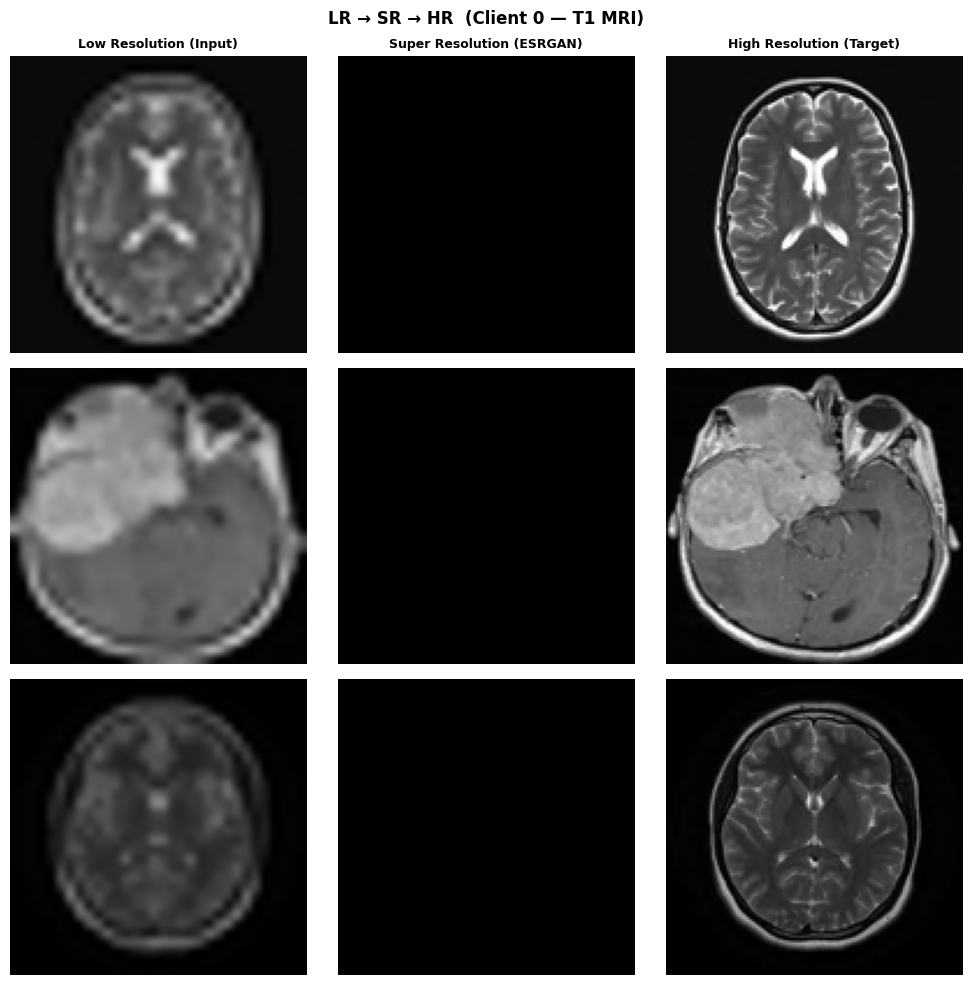

Saved: lr_sr_hr.png


In [16]:
global_model.eval()

# Bicubic baseline PSNR
def bicubic_psnr(loader):
    scores = []
    for lr_img, hr_img in loader:
        for i in range(lr_img.shape[0]):
            lr_np = lr_img[i,0].numpy()
            hr_np = hr_img[i,0].numpy()
            # bicubic is already baked into dataset — compare directly
            mse = ((lr_np - hr_np)**2).mean()
            if mse > 1e-10:
                scores.append(20 * math.log10(1.0 / math.sqrt(mse)))
    return round(np.mean(scores), 2) if scores else 0.0

bic_psnr = bicubic_psnr(eval_loader)
print(f"Bicubic PSNR (baseline): {bic_psnr} dB")
print(f"ESRGAN PSNR (federated): {history['psnr'][-1]} dB")
print(f"ESRGAN SSIM (federated): {history['ssim'][-1]}")

# Visual grid — show 3 samples
test_ds = MRIDataset(clients_data[0][:3])
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle("LR → SR → HR  (Client 0 — T1 MRI)", fontsize=12, fontweight="bold")
col_titles = ["Low Resolution (Input)", "Super Resolution (ESRGAN)", "High Resolution (Target)"]
for col, t in enumerate(col_titles):
    axes[0][col].set_title(t, fontsize=9, fontweight="bold")

for row in range(3):
    lr_t, hr_t = test_ds[row]
    with torch.no_grad():
        sr_t = global_model(lr_t.unsqueeze(0).to(device)).cpu().squeeze()
    imgs = [lr_t.squeeze(), sr_t, hr_t.squeeze()]
    for col, img in enumerate(imgs):
        axes[row][col].imshow(img.numpy(), cmap="gray", vmin=0, vmax=1)
        axes[row][col].axis("off")
        if col == 1:
            p = compute_psnr(sr_t.unsqueeze(0).unsqueeze(0), hr_t.unsqueeze(0))
            s = compute_ssim(sr_t.unsqueeze(0).unsqueeze(0), hr_t.unsqueeze(0))
            axes[row][col].set_xlabel(f"PSNR={p:.2f} | SSIM={s:.3f}", fontsize=8)

plt.tight_layout()
plt.savefig("lr_sr_hr.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: lr_sr_hr.png")


## 13 · Final Summary

In [17]:
torch.save(global_model.state_dict(), "global_esrgan_m17.pth")

print("=" * 52)
print("  FEDERATED ESRGAN — GROUP M17 — SUMMARY")
print("=" * 52)
print(f"  Rounds            : {ROUNDS}")
print(f"  Clients           : 3  (1 Byzantine simulated)")
print(f"  Non-IID split     : T1 / T2 / Low-field")
print(f"  DP sigma (σ)      : {DP_SIGMA}")
print(f"  Byz threshold     : {BYZ_THRESHOLD}")
print("-" * 52)
print(f"  Final PSNR        : {history['psnr'][-1]} dB")
print(f"  Final SSIM        : {history['ssim'][-1]}")
print(f"  Final ε           : {history['epsilon'][-1]}")
print(f"  Bicubic baseline  : {bic_psnr} dB")
print(f"  PSNR gain vs bicubic: {round(history['psnr'][-1] - bic_psnr, 2)} dB")
print("-" * 52)
print("  Rejected clients  :", [r for rnd in history['rejected'] for r in rnd])
print("  Model saved       : global_esrgan_m17.pth")
print("=" * 52)


  FEDERATED ESRGAN — GROUP M17 — SUMMARY
  Rounds            : 10
  Clients           : 3  (1 Byzantine simulated)
  Non-IID split     : T1 / T2 / Low-field
  DP sigma (σ)      : 1.1
  Byz threshold     : 0.65
----------------------------------------------------
  Final PSNR        : 10.136 dB
  Final SSIM        : 0.2164
  Final ε           : 0.1528
  Bicubic baseline  : 21.62 dB
  PSNR gain vs bicubic: -11.48 dB
----------------------------------------------------
  Rejected clients  : []
  Model saved       : global_esrgan_m17.pth
